# Goal: Fairness Metrics Computation
The goal of this notebook is given:
- a dataset D
- a target variable
- a sensible attribute
- a legittimate attribute (needed only for one specific metric)

it computes the statistical fairness metrics presented in Verma and Rubin paper https://dl.acm.org/doi/pdf/10.1145/3194770.3194776 + Aequitas metrics https://arxiv.org/pdf/1811.05577.pdf.

The running example is the Credit Score dataset https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk



## Only for Colab environment

In [1]:
#online for colab environment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
%cd /content/drive/MyDrive/USA/GermanCredit

/content/drive/MyDrive/USA/GermanCredit


#Import and Preprocessing

## Import Libraries

In [29]:
#import libraries
import numpy as np
import pandas as pd
np.random.seed(0)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix

## Load the dataset

In [7]:
dataset_path = 'german_credit_data.csv'
#dataset_path = 'german.csv'
df=pd.read_csv(dataset_path)
df.head(10)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
5,5,35,male,1,free,NaN,NaN,9055,36,education,good
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,7,35,male,3,rent,little,moderate,6948,36,car,good
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad


## Inputs

In [8]:
feature_cols= df.columns
target_variable = 'Risk'
target_variable_labels='bad','good'
sensible_attribute = "Sex"
#1 is the discriminated group, 0 the privileged one
sensible_values = [1, 0]
#only for conditional Statistical Parity metrics
legittimate_attribute = 'Saving accounts'
#if is not the first value is legittimate
legittimate_values = [0, 1]

## Preprocessing

In [9]:
df[feature_cols].isna().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [10]:
df = df.drop(columns=['Checking account', 'Purpose'])
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Credit amount,Duration,Risk
0,0,67,male,2,own,NaN,1169,6,good
1,1,22,female,2,own,little,5951,48,bad
2,2,49,male,1,own,little,2096,12,good
3,3,45,male,2,free,little,7882,42,good
4,4,53,male,2,free,little,4870,24,bad


In [11]:
print(len(df))
df = df.dropna()
df.head()
print(len(df))

1000
817


In [12]:
df['Sex'] = df['Sex'].replace({'male': 1, 'female': 0})
df.head()

<ipython-input-12-2c2e9de34d16>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({'male': 1, 'female': 0})


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Credit amount,Duration,Risk
1,1,22,0,2,own,little,5951,48,bad
2,2,49,1,1,own,little,2096,12,good
3,3,45,1,2,free,little,7882,42,good
4,4,53,1,2,free,little,4870,24,bad
6,6,53,1,2,own,quite rich,2835,24,good


In [13]:
print(df['Job'].unique())

[2 1 3 0]


In [14]:
print(df['Saving accounts'].unique())
df['Saving accounts'] = df['Saving accounts'].replace({'little': 0, 'quite rich': 1, 'moderate': 2, 'rich': 3})
df.head()

['little' 'quite rich' 'rich' 'moderate']


<ipython-input-14-23f90778c84b>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Saving accounts'] = df['Saving accounts'].replace({'little': 0, 'quite rich': 1, 'moderate': 2, 'rich': 3})


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Credit amount,Duration,Risk
1,1,22,0,2,own,0,5951,48,bad
2,2,49,1,1,own,0,2096,12,good
3,3,45,1,2,free,0,7882,42,good
4,4,53,1,2,free,0,4870,24,bad
6,6,53,1,2,own,1,2835,24,good


In [15]:
print(df['Housing'].unique())
df['Housing'] = df['Housing'].replace({'free': 0, 'rent': 1, 'own': 2})
df.head()

['own' 'free' 'rent']


<ipython-input-15-cd24134de74a>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Housing'] = df['Housing'].replace({'free': 0, 'rent': 1, 'own': 2})


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Credit amount,Duration,Risk
1,1,22,0,2,2,0,5951,48,bad
2,2,49,1,1,2,0,2096,12,good
3,3,45,1,2,0,0,7882,42,good
4,4,53,1,2,0,0,4870,24,bad
6,6,53,1,2,2,1,2835,24,good


In [16]:
df['Risk'] = df['Risk'].replace({'bad': 0, 'good': 1})
df.head()

<ipython-input-16-e5e2a038919e>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Risk'] = df['Risk'].replace({'bad': 0, 'good': 1})


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Credit amount,Duration,Risk
1,1,22,0,2,2,0,5951,48,0
2,2,49,1,1,2,0,2096,12,1
3,3,45,1,2,0,0,7882,42,1
4,4,53,1,2,0,0,4870,24,0
6,6,53,1,2,2,1,2835,24,1


#Apply Machine Learning Classification algorithm

## Spitting betwenn train and test sets

In [17]:
#save the two groups indexes
Y = df[target_variable]
X = df.drop(target_variable, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)
#y_true=df[target_variable].loc[list(X_test.index)]
sensible_indexes=df[sensible_attribute].loc[list(X_test.index)]
legittimate_indexes=df[legittimate_attribute].loc[list(X_test.index)]

In [18]:
#save the two groups indexes
discriminated = []
privileged = []
for idx, i in enumerate(sensible_indexes):
  if i==sensible_values[0]:
    discriminated.append(sensible_indexes.index[idx])
  else:
    privileged.append(sensible_indexes.index[idx])

In [19]:
#To compute the Conditional Statistical Parity we need a legittimate attribute L and save the indexes accordingly
legittimate = []
for idx, i in enumerate(legittimate_indexes):
  if i!=legittimate_values[0]:
    legittimate.append(legittimate_indexes.index[idx])

## Apply Standard Scaler for better performances

In [21]:
# scaling numering features
# numcols = ['Age', 'Job', 'Sex', 'Housing', 'Saving accounts', 'Credit amount', 'Duration']
# scaler = StandardScaler().fit(df[numcols])
# df_scaled = df.copy()
# df_scaled[numcols] = scaler.transform(df[numcols])
# df_scaled.head()

In [22]:
Y = df[target_variable]
X = df.drop(target_variable, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

In [23]:
#Apply Random Forest Classification
model = RandomForestClassifier().fit(X_train,y_train)
y_pred = model.predict(X_test)

In [24]:
print(len(y_test))

246


## Compute Performance Metrics

In [25]:
cm =confusion_matrix(y_test, y_pred)
print(cm)

[[ 30  58]
 [ 11 147]]


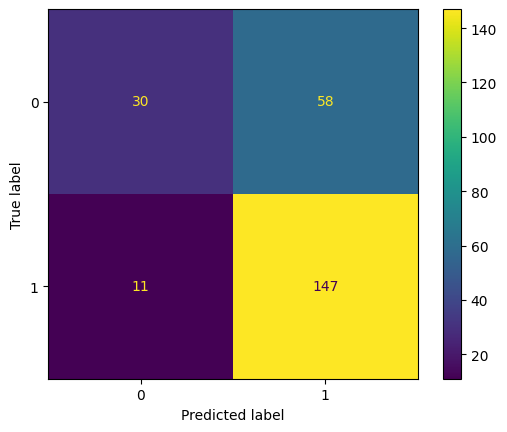

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
print(ConfusionMatrixDisplay.from_estimator(model,X_test, y_test))

In [27]:
TN = cm[0][0]
TP = cm[1][1]
FN = cm[1][0]
FP = cm[0][1]

In [28]:
## to do: add more performance metrics
Accuracy = (TP+TN)/(TP+TN+FP+FN)
Accuracy
#precision, recall, F1

0.7195121951219512

In [35]:
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
accuracy = metrics.accuracy_score(y_test, y_pred)
f1_score = metrics.f1_score(y_test, y_pred)
print("Precision: "+str(precision)+ ", Recall: "+str(recall)+ ", Accuracy: "+str(accuracy)+", F1: "+str(f1_score))

Precision: 0.7170731707317073, Recall: 0.930379746835443, Accuracy: 0.7195121951219512, F1: 0.8099173553719008


## Compute Fairness Confusion Matrx
### We need to distingish between y_pred and y_test of discriminated and favoured groups

In [36]:
y_test_discriminated= y_test.loc[list(discriminated)]
y_test_privileged= y_test.loc[list(privileged)]
print(len(y_test_privileged), len(y_test_discriminated))

90 156


In [37]:
#basic computation to add indexes to prediction array
temporary = list()
for idx, i in enumerate(y_test.index):
  temporary.append((i, y_pred[idx]))

y_pred_df = pd.DataFrame (temporary, columns = ['index', 'y_pred'])
y_pred_df.set_index(keys=y_pred_df['index'],inplace = True)
y_pred_df.drop(columns='index', axis=1, inplace= True)

In [38]:
y_pred_discriminated= y_pred_df.loc[list(discriminated)]
y_pred_privileged= y_pred_df.loc[list(privileged)]
print(len(y_pred_privileged), len(y_pred_discriminated))

90 156


In [39]:
from sklearn.metrics import confusion_matrix
cm_discriminated =confusion_matrix(y_test_discriminated, y_pred_discriminated)
print(cm_discriminated)

TP_discr = cm_discriminated[1][1]
TN_discr = cm_discriminated[0][0]
FN_discr = cm_discriminated[1][0]
FP_discr = cm_discriminated[0][1]

[[14 39]
 [ 5 98]]


In [40]:
cm_privileged =confusion_matrix(y_test_privileged, y_pred_privileged)
print(cm_privileged)

TP_priv = cm_privileged[1][1]
TN_priv = cm_privileged[0][0]
FN_priv = cm_privileged[1][0]
FP_priv = cm_privileged[0][1]

[[16 19]
 [ 6 49]]


In [41]:
print(len(discriminated), len(privileged))

156 90


In [42]:
#To compute the Conditional Statistical Parity we need a legittimate attribute L and compiute the confusion matrix accordingly
y_test_discriminated_legittimate= y_test_discriminated.loc[y_test_discriminated.index.isin(list(legittimate))]
y_test_privileged_legittimate= y_test_privileged.loc[y_test_privileged.index.isin(list(legittimate))]
print(len(y_test_privileged_legittimate), len(y_test_discriminated_legittimate))

y_pred_discriminated_legittimate= y_pred_discriminated.loc[y_pred_discriminated.index.isin(list(legittimate))]
y_pred_privileged_legittimate= y_pred_privileged.loc[y_pred_privileged.index.isin(list(legittimate))]
print(len(y_pred_privileged_legittimate), len(y_pred_discriminated_legittimate))


22 32
22 32


In [43]:
cm_leg_privileged =confusion_matrix(y_test_privileged_legittimate, y_pred_privileged_legittimate)
print(cm_leg_privileged)

TP_leg_priv = cm_leg_privileged[1][1]
TN_leg_priv = cm_leg_privileged[0][0]
FN_leg_priv = cm_leg_privileged[1][0]
FP_leg_priv = cm_leg_privileged[0][1]

cm_leg_discriminated =confusion_matrix(y_test_discriminated_legittimate, y_pred_discriminated_legittimate)
print(cm_leg_discriminated)

TP_leg_discr = cm_leg_discriminated[1][1]
TN_leg_discr = cm_leg_discriminated[0][0]
FN_leg_discr = cm_leg_discriminated[1][0]
FP_leg_discr = cm_leg_discriminated[0][1]

[[ 1  4]
 [ 0 17]]
[[ 2  4]
 [ 0 26]]


# Fairness Metrics Computation


###Terminology:
- d is the predicted value,
- Y is the actual value in the dataset
- G the protected attribute, priv= privileged group, discr=discriminated group
- L is the legittimate attribute (only for Conditional Statistical Parity)

###Fairness Metrics List:
##### 1. Group Fairness: (d=1|G=priv) = (d=1|G=discr)
##### 2. Conditional Statistical Parity: (d=1|L=l, G=priv) = (d=1|L=l,G=discr)
##### 3. Predictive Parity: (Y=1|d=1,G=priv) = (Y=1|d=1,G=discr)
##### 4. Predictive Equality: (d=1|Y=0,G=priv) = (d=1|Y=0,G=discr)
##### 5. Equal Opportunity:  (d=0|Y=1,G=priv) = (d=0|Y=1,G=discr)
##### 6. Equalized Odds: (d=1|Y=i,G=priv) = (d=1|Y=i,G=discr), i ∈ 0,1
##### 7. ConditionalUseAccuracyEquality: (Y=1|d=1, G=priv) = (Y=1|d=1,G=discr) and (Y=0|d=0,G=priv) = (Y=0|d=0,G=discr)
##### 8. Overall Accuracy Equality: (d=Y, G=priv) = (d=Y, G=priv)
##### 9. Treatment Equality: (Y=1, d=0, G=priv)/(Y=0, d=1, G=priv) = (Y=1, d=0, G=discr)/(Y=0, d=1, G=discr)
##### 10. FOR Parity: (Y=1|d=0, G=priv) = (Y=1|d=0,G=discr)  

In [ ]:
GroupFairness_discr = (TP_discr+FP_discr)/len(discriminated)
GroupFairness_priv = (TP_priv+FP_priv)/len(privileged)
GroupFairness = GroupFairness_discr/GroupFairness_priv

ConditionalStatisticalParity_discr = (TP_leg_discr+FP_leg_discr)/len(y_pred_discriminated_legittimate)
ConditionalStatisticalParity_priv = (TP_leg_priv+FP_leg_priv)/len(y_pred_privileged_legittimate)
ConditionalStatisticalParity = ConditionalStatisticalParity_discr/ConditionalStatisticalParity_priv

PredictiveParity_discr = (TP_discr)/(TP_discr+FP_discr)
PredictiveParity_priv = (TP_priv)/(TP_priv+FP_priv)
PredictiveParity = PredictiveParity_discr/PredictiveParity_priv

PredictiveEquality_discr = (FP_discr)/(TN_discr+FP_discr)
PredictiveEquality_priv = (FP_priv)/(TN_priv+FP_priv)
PredictiveEquality = PredictiveEquality_discr/PredictiveEquality_priv

EqualOpportunity_discr = (FN_discr)/(TP_discr+FN_discr)
EqualOpportunity_priv = (FN_priv)/(TP_priv+FN_priv)
EqualOpportunity = EqualOpportunity_priv/EqualOpportunity_discr

EqualizedOdds1 = ((TP_discr/(TP_discr+FN_discr)) / (TP_priv/(TP_priv+FN_priv))) #(1-equalOpportunity_discr)/(1-equalOpportunity_priv)
EqualizedOdds2 = ((FP_discr/(TN_discr+FP_discr)) / (FP_priv/(TN_priv+FP_priv))) #= PredictiveEquality
EqualizedOdds = (EqualizedOdds1*EqualizedOdds2)

ConditionalUseAccuracyEquality1 = ((TP_discr/(TP_discr+FP_discr)) / (TP_priv/(TP_priv+FP_priv)))
ConditionalUseAccuracyEquality2 = ((TN_discr/(TN_discr+FN_discr)) / (TN_priv/(TN_priv+FN_priv)))
ConditionalUseAccuracyEquality = (ConditionalUseAccuracyEquality1*ConditionalUseAccuracyEquality2)

OAE1 = TP_discr/TP_priv
OAE2 = TN_discr/TN_priv
OverallAccuracyEquality = (OAE1*OAE2)

TreatmentEquality_discr = (FN_discr/FP_discr)*len(discriminated)
TreatmentEquality_priv = (FN_priv/FP_priv)*len(privileged)

TreatmentEquality = TreatmentEquality_priv/TreatmentEquality_discr

FORParity_discr = (FN_discr)/(TN_discr+FN_discr)
FORParity_priv = (FN_priv)/(TN_priv+FN_priv)
FORParity = FORParity_priv/FORParity_discr

FN_P_discr =  (FN_discr)/len(discriminated)
FN_P_priv =  (FN_priv)/len(privileged)

FP_P_discr = (FP_discr)/len(discriminated)
FP_P_priv =  (FP_priv)/len(privileged)

#RecallParity = (TP_discr/(TP_discr+FN_discr))/(TP_priv/(TP_priv+FN_priv))

metrics = []
metrics.append(('GroupFairness',  GroupFairness, GroupFairness_discr, GroupFairness_priv))
metrics.append(('ConditionalStatisticalParity',  ConditionalStatisticalParity, ConditionalStatisticalParity_discr, ConditionalStatisticalParity_priv))
metrics.append(('PredictiveParity', PredictiveParity, PredictiveParity_discr, PredictiveParity_priv))
metrics.append(('PredictiveEquality', PredictiveEquality, PredictiveEquality_discr, PredictiveEquality_priv))
metrics.append(('EqualOpportunity', EqualOpportunity, EqualOpportunity_discr, EqualOpportunity_priv))
metrics.append(('EqualizedOdds', EqualizedOdds, EqualizedOdds1, EqualizedOdds2))
metrics.append(('ConditionalUseAccuracyEquality', ConditionalUseAccuracyEquality, ConditionalUseAccuracyEquality1 , ConditionalUseAccuracyEquality2))
metrics.append(('OverallAccuracyEquality', OverallAccuracyEquality, OAE1, OAE2))
metrics.append(('TreatmentEquality', TreatmentEquality, TreatmentEquality_discr, TreatmentEquality_priv))
metrics.append(('FORParity', FORParity, FORParity_discr, FORParity_priv))
metrics.append(('FN', FN_P_priv/FN_P_discr, FN_P_discr, FN_P_priv))
metrics.append(('FP', FP_P_discr/FP_P_priv, FP_P_discr, FP_P_priv))


In [ ]:
fairness_metrics = pd.DataFrame(metrics, columns = ['Metric', 'Value', 'Value_discriminated_group', 'Value_privileged_group'])
fairness_metrics.head(len(fairness_metrics))

,Metric,Value,Value_discriminated_group,Value_privileged_group
0,GroupFairness,0.853922,0.744444,0.871795
1,ConditionalStatisticalParity,0.969697,0.909091,0.937500
2,PredictiveParity,0.993331,0.686567,0.691176
3,PredictiveEquality,0.757143,0.600000,0.792453
4,EqualOpportunity,0.533981,0.163636,0.087379
5,EqualizedOdds,0.693877,0.916441,0.757143
6,ConditionalUseAccuracyEquality,1.099339,0.993331,1.106719
7,OverallAccuracyEquality,0.622824,0.489362,1.272727
8,TreatmentEquality,0.866667,38.571429,33.428571
9,FORParity,1.150000,0.391304,0.450000


### How to evaluate the results?
Looking at the value for each corresponding metric:

- If the value is between 0 and 1-t the discriminated group suffers from unfairness
- If the value is greater than 1+t the privileged group suffers from unfairness
- If the value is between 1-t and 1+t both privileged and discriminated group have a fair treatment

t is a threshold that should be choose by the user according to the context and the goal of the task.


In [ ]:
print(TP_leg_priv, FP_leg_priv, len(y_pred_discriminated_legittimate))

26 4 22
